### Scattering Phase Matrix (Mueller Matrix)

$$
\begin{bmatrix}
I_s \\
Q_s \\
U_s \\
V_s
\end{bmatrix}
=\frac{1}{k^2 r^2}
\, \mathbf{P}(\theta)
\begin{bmatrix}
I_i \\
Q_i \\
U_i \\
V_i
\end{bmatrix}
$$

$$
\Rightarrow
\begin{bmatrix}
I_s \\
Q_s \\
U_s \\
V_s
\end{bmatrix}
=\frac{1}{k^2 r^2}
\begin{bmatrix}
P_{11}(\theta) & P_{12}(\theta) & 0 & 0 \\
P_{21}(\theta) & P_{22}(\theta) & 0 & 0 \\
0 & 0 & P_{33}(\theta) & P_{34}(\theta) \\
0 & 0 & -P_{34}(\theta) & P_{44}(\theta)
\end{bmatrix}
\begin{bmatrix}
I_i \\
Q_i \\
U_i \\
V_i
\end{bmatrix}
$$

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=[12,4], tight_layout=True)
ax[0].imshow(RGB_image)
ax[0].set_title('RGB image',fontsize='large')

re_img = ax[1].imshow(re_best_fit,vmin=5,vmax=20)
ax[1].set_title(r'$r_e$ retrieval',fontsize='large')
plt.colorbar(re_img,ax=ax[1],extend='max') 

ve_img=ax[2].imshow(ve_best_fit,vmin=0.01,vmax=0.05,cmap='plasma_r')
ax[2].set_title(r'$v_e$ retrieval',fontsize='large')
plt.colorbar(ve_img,ax=ax[2],extend='max')

plt.savefig('no_muv_normalization.png')

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# plot 1:
img1 = axes[0].pcolormesh(lon, lat, cer, cmap='jet', shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[0].set_title('Cloud Effective Radius (CER)', fontweight='bold')

gl1 = axes[0].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

cbar1 = plt.colorbar(img1, ax=axes[0], orientation='vertical', shrink=0.7)
cbar1.set_label('CER (µm)')


# plot 2:
img2 = axes[1].pcolormesh(lon, lat, cev, cmap='jet', shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[1].set_title('Cloud Effective Variance (CEV)', fontweight='bold')

gl2 = axes[1].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = False     # Remove left labels for middle plot (cleaner look)

cbar2 = plt.colorbar(img2, ax=axes[1], orientation='vertical', shrink=0.7)
cbar2.set_label('CEV')


# plot 3:
img3 = axes[2].pcolormesh(lon, lat, cdnc, cmap='jet', vmax=250, shading='auto')
axes[2].coastlines()
axes[2].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[2].set_title('Cloud Droplet Number Concentration (CDNC)', fontweight='bold')

gl3 = axes[2].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl3.top_labels = False
gl3.left_labels = False  

cbar3 = plt.colorbar(img3, ax=axes[2], orientation='vertical', shrink=0.7)
cbar3.set_label('CDNC (cm$^{-3}$)')

plt.tight_layout()
plt.show()

In [ ]:
# Example variables:
# cdnc_jan, cdnc_feb, cdnc_mar
# lon, lat already defined

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

vmin = 0
vmax = 250  

months = ['January', 'February', 'March']
cdnc_data = [cdnc_june, cdnc_july, cdnc_aug]

for ax, data, month in zip(axes, cdnc_data, months):

    img = ax.pcolormesh(lon, lat, data, cmap='jet', vmin=vmin, vmax=vmax, shading='auto')

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
    ax.set_title(f'CDNC - {month}', fontweight='bold')

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # remove repeated latitude labels for middle & right plots
    if ax != axes[0]:
        gl.left_labels = False

cbar = fig.colorbar(img, ax=axes, orientation='vertical', shrink=0.75)
cbar.set_label('CDNC (cm$^{-3}$)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# ---- File Paths (define once) ----
# =====================================================
file_path_L1  = 'PACE_OCI.20250822T123146.L1B.V3.nc'
file_path_L2A = 'PACE_OCI.20250822T123146.L2.AER_UAA.V3_1.nc'
file_path_L2C = 'PACE_OCI.20250822T123146.L2.CLD.V3_1.nc'

# =====================================================
# ---- Extract Date + Time From Filename (Suptitle + save name) ----
# =====================================================
filename = os.path.basename(file_path_L1)
datetime_str = filename.split(".")[1]  # e.g., 20250904T120059
dt = datetime.strptime(datetime_str, "%Y%m%dT%H%M%S")
formatted_datetime = dt.strftime("%B %d, %Y %H:%M UTC")

# Safe filename for saving (no spaces/commas/colons)
safe_filename = dt.strftime("%Y%m%d_%H%MUTC")

# =====================================================
# ---- Load L1 RGB DATA ----
# =====================================================
data_L1 = xr.open_dataset(file_path_L1, group='observation_data')
geo_L1  = xr.open_dataset(file_path_L1, group='geolocation_data')

rgb = np.zeros((1710, 1272, 3))

blue  = data_L1['rhot_blue'][64, :, :]
red   = data_L1['rhot_red'][33, :, :]
green = data_L1['rhot_blue'][92, :, :]

factor = 0.4
rgb[:, :, 0] = red   / factor
rgb[:, :, 1] = green / factor
rgb[:, :, 2] = blue  / factor

rgb[rgb > 1] = 1.0
rgb[rgb < 0] = 0.0

# =====================================================
# ---- Load L2 AOD DATA ----
# =====================================================
data_L2A = xr.open_dataset(file_path_L2A, group='geophysical_data')
geo_L2A  = xr.open_dataset(file_path_L2A, group='geolocation_data')

aod_raw = data_L2A['NUV_AerosolOpticalDepthOverCloud']
aod_2d  = aod_raw.isel(Wavelength_Used_UV=2)  # pick one UV channel (0/1/2)

# =====================================================
# ---- Load L2 Cloud (CER/COT) DATA ----
# =====================================================
data_L2C = xr.open_dataset(file_path_L2C, group='geophysical_data')
geo_L2C  = xr.open_dataset(file_path_L2C, group='navigation_data')

cer_2d = data_L2C['cer_21']
cot_2d = data_L2C['cot_21']

# =====================================================
# ---- Colormaps (set NaN color) ----
# =====================================================
cmap_aod = plt.colormaps['jet'].copy()
cmap_aod.set_bad('lightgray')

cmap_cer = plt.colormaps['jet'].copy()
cmap_cer.set_bad('lightgray')

cmap_cot = plt.colormaps['jet'].copy()
cmap_cot.set_bad('lightgray')

# =====================================================
# ---- Figure Layout: 2x2 plots, each with its own colorbar column ----
# Columns: [plot, cbar, plot, cbar]
# This keeps ALL plot panels the same size.
# =====================================================
fig = plt.figure(figsize=(18, 12))

gs = gridspec.GridSpec(
    2, 4,
    width_ratios=[1, 0.045, 1, 0.045],
    wspace=0.2,
    hspace=0.08
)

# Axes
ax_rgb = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
cax_rgb = fig.add_subplot(gs[0, 1])  # (unused; keep for alignment)

ax_aod = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
cax_aod = fig.add_subplot(gs[0, 3])

ax_cer = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
cax_cer = fig.add_subplot(gs[1, 1])

ax_cot = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())
cax_cot = fig.add_subplot(gs[1, 3])

# Turn off the RGB "colorbar axis" but keep the space
cax_rgb.axis("off")

# =====================================================
# ---- Plot: RGB ----
# =====================================================
ax_rgb.pcolormesh(geo_L1.longitude, geo_L1.latitude, rgb, shading="nearest", rasterized=True, 
                  transform=ccrs.PlateCarree())

# =====================================================
# ---- Plot: AOD ----
# =====================================================
pcm_aod = ax_aod.pcolormesh(geo_L2A.longitude, geo_L2A.latitude, aod_2d, shading="nearest", 
                            rasterized=True, transform=ccrs.PlateCarree(), cmap=cmap_aod, vmin=0.1, vmax=1.5)

# =====================================================
# ---- Plot: CER ----
# =====================================================
pcm_cer = ax_cer.pcolormesh(geo_L2C.longitude, geo_L2C.latitude, cer_2d, shading="nearest", rasterized=True, 
                            transform=ccrs.PlateCarree(), cmap=cmap_cer, vmin=0, vmax=40)

# =====================================================
# ---- Plot: COT ----
# =====================================================
pcm_cot = ax_cot.pcolormesh(geo_L2C.longitude, geo_L2C.latitude, cot_2d, shading="nearest", rasterized=True, 
                            transform=ccrs.PlateCarree(), cmap=cmap_cot, vmin=0, vmax=60)

# =====================================================
# ---- Styling helper (gridlines + features) ----
# =====================================================
def style_map(ax, left_labels=True):
    # ---- Set same geographic extent for ALL subplots ----
    ax.set_extent([5, 13, -12, -6], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    gl = ax.gridlines(draw_labels=True, dms=True,
                      x_inline=False, y_inline=False)

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = left_labels
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    return gl

# Left column keeps lat labels; right column removes lat labels
style_map(ax_rgb, left_labels=True)
style_map(ax_aod, left_labels=False)  # remove ylabel on right plot
style_map(ax_cer, left_labels=True)
style_map(ax_cot, left_labels=False)  # remove ylabel on right plot

# =====================================================
# ---- Colorbars (each gets its own dedicated axis; no shrinking) ----
# =====================================================
cbar_aod = fig.colorbar(pcm_aod, cax=cax_aod)
cbar_aod.set_label('Aerosol Optical Depth Over Cloud', fontsize=15, fontweight='bold')
cbar_aod.ax.tick_params(labelsize=12)
for t in cbar_aod.ax.get_yticklabels():
    t.set_fontweight('bold')

cbar_cer = fig.colorbar(pcm_cer, cax=cax_cer)
cbar_cer.set_label('Cloud Effective Radius (µm)', fontsize=15, fontweight='bold')
cbar_cer.ax.tick_params(labelsize=12)
for t in cbar_cer.ax.get_yticklabels():
    t.set_fontweight('bold')

cbar_cot = fig.colorbar(pcm_cot, cax=cax_cot)
cbar_cot.set_label('Cloud Optical Thickness', fontsize=15, fontweight='bold')
cbar_cot.ax.tick_params(labelsize=12)
for t in cbar_cot.ax.get_yticklabels():
    t.set_fontweight('bold')

# =====================================================
# ---- Super Title ----
# =====================================================
fig.suptitle(formatted_datetime, fontsize=22, fontweight='bold', y=0.92)

# =====================================================
# ---- Save Figure ----
# =====================================================
# plt.savefig(f"{safe_filename}.png", dpi=500, bbox_inches="tight")
plt.show()

# 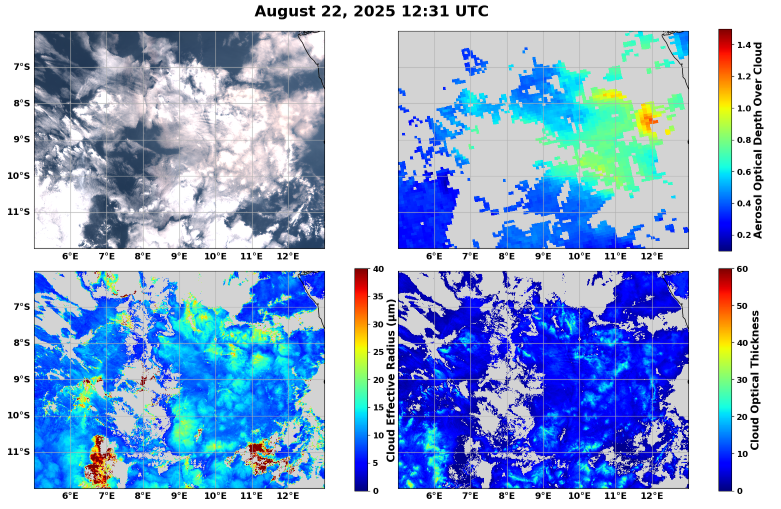